<a href="https://colab.research.google.com/github/another-lifechapter-anu20/EDA_Analysis-Python/blob/main/Titanic_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("=" * 50)
print("🚢 TITANIC EDA PROJECT")
print("=" * 50)

# 🔹 Load the Titanic dataset (built into Seaborn)
df = sns.load_dataset('titanic')
print("\n📊 Dataset loaded successfully!")
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {', '.join(df.columns)}")

# 🔹 First look
print("\n📋 First 5 rows:")
print(df.head())

🚢 TITANIC EDA PROJECT

📊 Dataset loaded successfully!
Shape: (891, 15) (rows, columns)
Columns: survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone

📋 First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no  

# Data Cleaning

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')

print("=" * 50)
print("🔍 DATA INSPECTION")
print("=" * 50)

# 🔹 Check for missing values
print("\n📊 Missing values per column:")
print(df.isnull().sum())

print(f"\n📊 Total missing: {df.isnull().sum().sum()}")
print(f"📊 Percentage missing: {df.isnull().sum().sum() / df.size * 100:.1f}%")

# 🔹 Data types
print("\n📊 Data types:")
print(df.dtypes)

print("\n" + "=" * 50)
print("🧹 DATA CLEANING")
print("=" * 50)

# 🔹 Create a copy to preserve original
df_clean = df.copy()

# 🔹 Fill missing 'age' with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
print("✅ Filled missing ages with median")

# 🔹 Fill missing 'embarked' with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
print("✅ Filled missing embarked with mode")

# 🔹 Drop 'deck' (too many missing values)
if 'deck' in df_clean.columns:
    df_clean = df_clean.drop(columns=['deck'])
    print("✅ Dropped 'deck' column (too many missing values)")

print(f"\n📊 Cleaned dataset shape: {df_clean.shape}")

🔍 DATA INSPECTION

📊 Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

📊 Total missing: 869
📊 Percentage missing: 6.5%

📊 Data types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

🧹 DATA CLEANING
✅ Filled missing ages with median
✅ Filled missing embarked with mode
✅ Dropped 'deck' column (too many missing values)

📊 Cleaned dataset shape: (891, 14)


# Visualizations

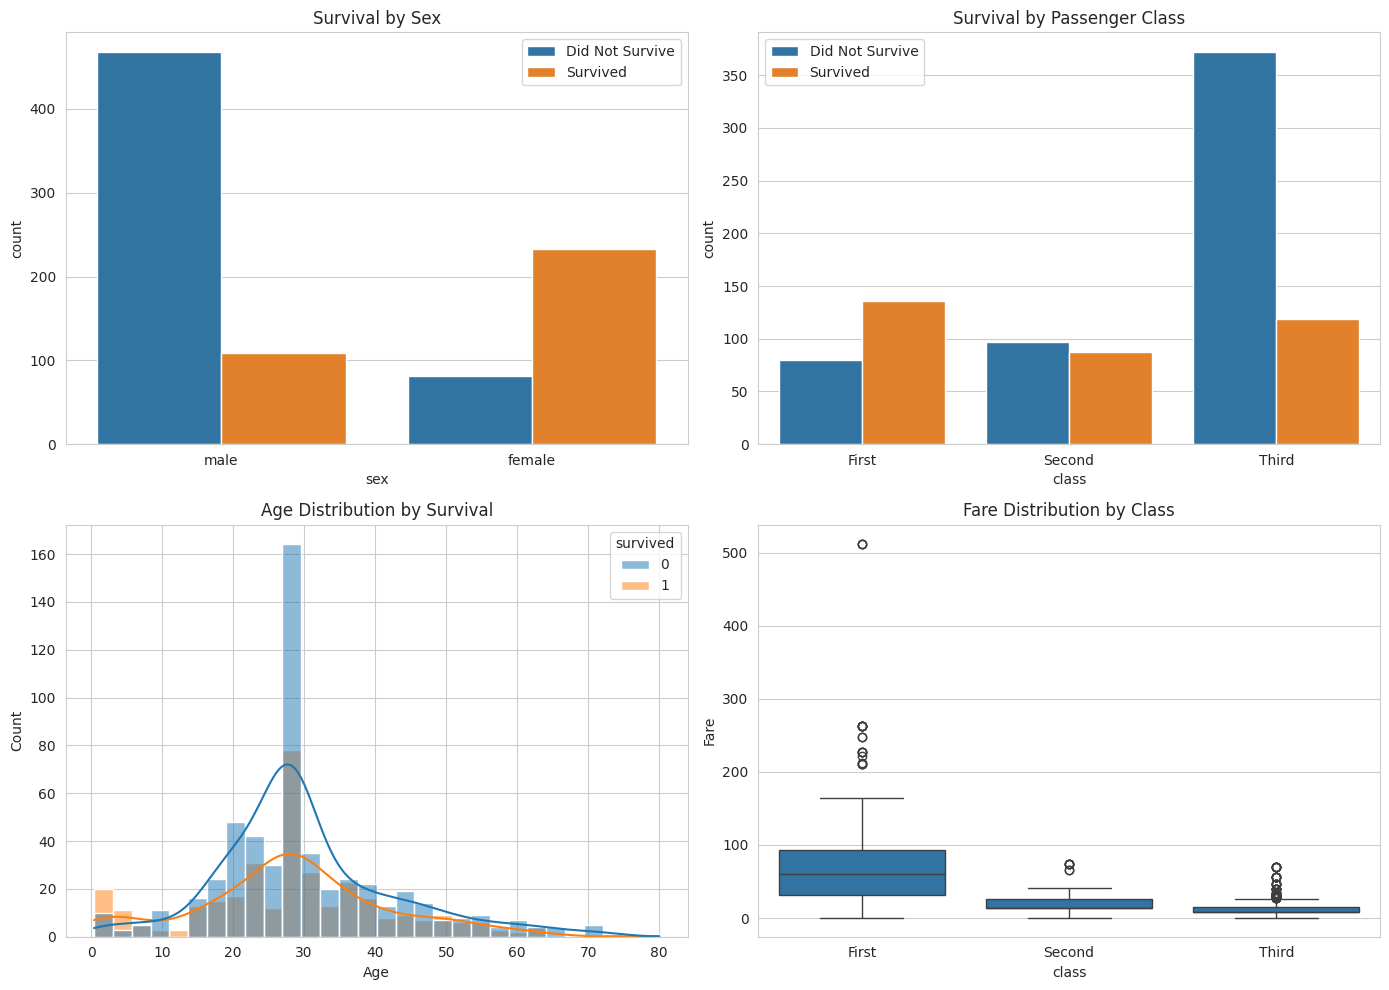

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')
df_clean = df.copy()
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 🔹 1. Survival by Sex
sns.countplot(x='sex', hue='survived', data=df_clean, ax=axes[0,0])
axes[0,0].set_title('Survival by Sex')
axes[0,0].legend(['Did Not Survive', 'Survived'])

# 🔹 2. Survival by Class
sns.countplot(x='class', hue='survived', data=df_clean, ax=axes[0,1])
axes[0,1].set_title('Survival by Passenger Class')
axes[0,1].legend(['Did Not Survive', 'Survived'])

# 🔹 3. Age distribution by Survival
sns.histplot(data=df_clean, x='age', hue='survived', bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Count')

# 🔹 4. Fare distribution by Class
sns.boxplot(x='class', y='fare', data=df_clean, ax=axes[1,1])
axes[1,1].set_title('Fare Distribution by Class')
axes[1,1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

 **Correlation Analysis**

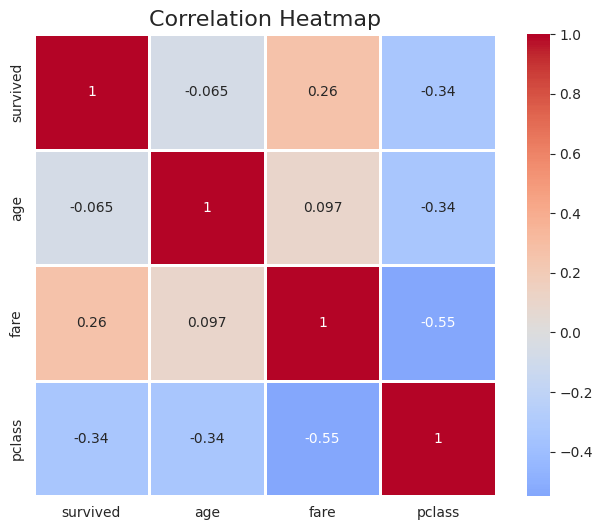


📊 Key Correlations:
Survival vs Pclass: -0.34 (negative = better class)
Survival vs Fare: 0.26
Survival vs Age: -0.06


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')
df_clean = df.copy()

# 🔹 Select numeric columns
numeric_cols = ['survived', 'age', 'fare', 'pclass']
df_numeric = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# 🔹 Calculate correlation
corr = df_numeric.corr()

# 🔹 Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

# 🔹 Key insights
print("\n📊 Key Correlations:")
print(f"Survival vs Pclass: {corr['survived']['pclass']:.2f} (negative = better class)")
print(f"Survival vs Fare: {corr['survived']['fare']:.2f}")
print(f"Survival vs Age: {corr['survived']['age']:.2f}")